In [45]:
import glob
import os
import re
import sys
sys.path.append(sys.path[0] + "/..")

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import numpy.lib.recfunctions as rf
import pandas as pd
import pytorch_lightning as pl
from pytorch_lightning.callbacks import RichProgressBar
from pytorch_lightning.callbacks.progress.rich_progress import RichProgressBarTheme
from pytorch_lightning.callbacks import ModelCheckpoint
import scipy.io
import segmentation_models_pytorch as smp
from sklearn.neighbors import KDTree
import torch
import torch.nn as nn
import torch.multiprocessing as mp
import torch.utils.checkpoint
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from tqdm import tqdm
import wandb

from data_preparation import data_preparation
from loaders.rad_cube_loader import RADCUBE_DATASET_TIME
from networks.network_time import NeuralNetworkRadarDetector
from utils.compute_metrics import compute_metrics_time, compute_pd_pfa

In [46]:
# Force CUDA initialization
if torch.cuda.is_available():
    # torch.cuda.init()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    # torch.set_float32_matmul_precision('medium')

params = data_preparation.get_default_params()

# Initialise parameters
params["dataset_path"] = '/media/muckelroyiii/Mass-Storage/RaDelft'
params["train_val_scenes"] = [1, 3, 4, 5, 7]
params["test_scenes"] = [2, 6]
params["train_test_split_percent"] = 0.8
params["use_npy_cubes"] = False
params["cfar_folder"] = 'radar_ososos'
params['label_smoothing'] = False
params["quantile"] = False

# This must be kept to false. If the network without elevation is needed, use network_noElevation.py instead
params["bev"] = False

In [47]:
def create_transformation_matrix(roll, pitch, yaw, translation_vector):
    """
    Create a transformation matrix from roll, pitch, yaw angles (in degrees) and a translation vector.

    Args:
    roll (float): Roll angle in degrees.
    pitch (float): Pitch angle in degrees.
    yaw (float): Yaw angle in degrees.
    translation_vector (list): A list of three elements representing the translation vector.

    Returns:
    numpy.ndarray: A 4x4 transformation matrix.
    """
    # Convert angles from degrees to radians
    roll_rad = np.radians(roll)
    pitch_rad = np.radians(pitch)
    yaw_rad = np.radians(yaw)

    # Create individual rotation matrices
    R_x = np.array([[1, 0, 0],
                    [0, np.cos(roll_rad), -np.sin(roll_rad)],
                    [0, np.sin(roll_rad), np.cos(roll_rad)]])

    R_y = np.array([[np.cos(pitch_rad), 0, np.sin(pitch_rad)],
                    [0, 1, 0],
                    [-np.sin(pitch_rad), 0, np.cos(pitch_rad)]])

    R_z = np.array([[np.cos(yaw_rad), -np.sin(yaw_rad), 0],
                    [np.sin(yaw_rad), np.cos(yaw_rad), 0],
                    [0, 0, 1]])

    # Combined rotation matrix
    R = np.dot(R_z, np.dot(R_y, R_x))

    # rotate around y axis again h degrees
    h = 1
    h_rad = np.radians(h)
    R_h = np.array([[np.cos(h_rad), 0, np.sin(h_rad)],
                    [0, 1, 0],
                    [-np.sin(h_rad), 0, np.cos(h_rad)]])

    R = np.dot(R_h, R)
    # Create the transformation matrix
    transformation_matrix = np.eye(4)
    transformation_matrix[:3, :3] = R
    transformation_matrix[:3, 3] = translation_vector

    return transformation_matrix


def get_sensor_transforms():
    calibration_file = "./utils/calib.txt"
    with open(calibration_file, "r") as f:
        lines = f.readlines()
        intrinsic = np.array(lines[2].strip().split(' ')[1:], dtype=np.float32).reshape(3, 4)  # Intrinsics
        extrinsic = np.array(lines[5].strip().split(' ')[1:], dtype=np.float32).reshape(3, 4)  # Extrinsic
        extrinsic = np.concatenate([extrinsic, [[0, 0, 0, 1]]], axis=0)

    camera_projection_matrix, T_camera_lidar = intrinsic, extrinsic

    return camera_projection_matrix, T_camera_lidar


def homogeneous_transformation(points: np.ndarray, transform: np.ndarray) -> np.ndarray:
    """
This function applies the homogenous transform using the dot product.
    :param points: Points to be transformed in a Nx4 numpy array.
    :param transform: 4x4 transformation matrix in a numpy array.
    :return: Transformed points of shape Nx4 in a numpy array.
    """
    if transform.shape != (4, 4):
        raise ValueError(f"{transform.shape} must be 4x4!")
    if points.shape[1] != 4:
        raise ValueError(f"{points.shape[1]} must be Nx4!")
    return transform.dot(points.T).T


def project_3d_to_2d(points: np.ndarray, projection_matrix: np.ndarray):
    """
This function projects the input 3d ndarray to a 2d ndarray, given a projection matrix.
    :param points: Homogenous points to be projected.
    :param projection_matrix: 4x4 projection matrix.
    :return: 2d ndarray of the projected points.
    """
    if points.shape[-1] != 4:
        raise ValueError(f"{points.shape[-1]} must be 4!")

    uvw = projection_matrix.dot(points.T)
    uvw /= uvw[2]
    uvs = uvw[:2].T
    uvs = np.round(uvs).astype(int)

    return uvs


def project_pcl_to_image(point_cloud, t_camera_pcl, camera_projection_matrix, image_shape):
    """
A helper function which projects a point clouds specific to the dataset to the camera image frame.
    :param point_cloud: Point cloud to be projected.
    :param t_camera_pcl: Transformation from the pcl frame to the camera frame.
    :param camera_projection_matrix: The 4x4 camera projection matrix.
    :param image_shape: Size of the camera image.
    :return: Projected points, and the depth of each point.
    """
    point_homo = np.hstack((point_cloud[:, :3], np.ones((point_cloud.shape[0], 1))))

    radar_points_camera_frame = homogeneous_transformation(point_homo,
                                                           transform=t_camera_pcl)

    point_depth = radar_points_camera_frame[:, 2]

    uvs = project_3d_to_2d(points=radar_points_camera_frame,
                           projection_matrix=camera_projection_matrix)

    filtered_idx = canvas_crop(points=uvs,
                               image_size=image_shape,
                               points_depth=point_depth)

    # uvs = uvs[filtered_idx]
    # point_depth = point_depth[filtered_idx]

    return uvs, point_depth, filtered_idx


def canvas_crop(points, image_size, points_depth=None):
    """
This function filters points that lie outside a given frame size.
    :param points: Input points to be filtered.
    :param image_size: Size of the frame.
    :param points_depth: Filters also depths smaller than 0.
    :return: Filtered points.
    """
    idx = points[:, 0] > 0
    idx = np.logical_and(idx, points[:, 0] < image_size[1])
    idx = np.logical_and(idx, points[:, 1] > 0)
    idx = np.logical_and(idx, points[:, 1] < image_size[0])
    if points_depth is not None:
        idx = np.logical_and(idx, points_depth > 0)

    return idx


# function that takes axis and 2d points and plots them
def plot_points_on_image(ax, cax, points_2d, image, point_depths=None, size=40, color_by='depth', alpha=0.1):
    ax.imshow(image)
    if color_by == "depth" and point_depths is not None:
        # print("color by depth")
        order = np.argsort(-point_depths)
        point_depths = point_depths[order]
        points_2d = points_2d[order, :]

        im = ax.scatter(points_2d[:, 0], points_2d[:, 1], c=point_depths, s=size, alpha=alpha)
        cb = ax.figure.colorbar(im, cax=cax)
        cb.solids.set(alpha=1)
        cb.set_label('Range (m)')
    elif color_by == "height":
        print("color by height")
        ax.scatter(points_2d[:, 0], points_2d[:, 1], c=points_2d[:, 1], s=size)

    elif color_by == "depth_scale":
        print("color by depth scale")
        ax.scatter(points_2d[:, 0], points_2d[:, 1], c=point_depths, s=3 / point_depths * point_depths)
        # scale dots based on depth

    ax.axis('off')
    return cb


# filter by distance
def filter_by_distance(point_depths, threshold):
    """
This function filters points that are further than a given distance.
    :param points: Input points to be filtered.
    :param distance: Distance threshold.
    :return: Filtered points.
    """
    return point_depths < threshold


def filter_point_cloud(point_cloud):
    # remove behind sensor:
    point_cloud = point_cloud[point_cloud[:, 0] > 0, :]

    # remove to far in x
    point_cloud = point_cloud[point_cloud[:, 0] < 30, :]

    # remove to far in y
    point_cloud = point_cloud[point_cloud[:, 1] < 10, :]
    point_cloud = point_cloud[point_cloud[:, 1] > -10, :]

    return point_cloud


def plot_bev(pointcloud, ax, cax, cblabel=True):
    """
This function plots the BEV of a point cloud.
    :param pointcloud: Input point cloud.
    :param ax: Matplotlib axis.
    :param cax: Colorbar Axis.
    """
    # colored by height
    im = ax.scatter(-pointcloud[:, 1], pointcloud[:, 0], c=pointcloud[:, 2], s=0.1)
    ax.set_xlim(-16, 16)
    ax.set_ylim(5, 30)
    ax.set_xlabel('y [m]')
    ax.set_xlabel('y [m]')
    ax.set_ylabel('x [m]')
    ax.set_aspect('equal')

    cb = ax.figure.colorbar(im, cax=cax)

    if cblabel == True:
        cb.set_label('Height (m)')

    return cb

# From the paper
def compute_chamfer_distance(point_cloud1, point_cloud2):
    """
    Compute the Chamfer distance between two set of points

    :param point_cloud1: the first set of points
    :param point_cloud2: the second set of points
    :return: the Chamfer distance
    """
    if len(point_cloud1) == 0 or len(point_cloud2) == 0:
        return float('inf')  # Return infinity if either point cloud is empty
        
    tree1 = KDTree(point_cloud1, metric='euclidean')
    tree2 = KDTree(point_cloud2, metric='euclidean')
    distances1, _ = tree1.query(point_cloud2)
    distances2, _ = tree2.query(point_cloud1)
    av_dist1 = np.sum(distances1) / np.size(distances1)
    av_dist2 = np.sum(distances2) / np.size(distances2)
    dist = av_dist1 + av_dist2

    return dist

transform = transforms.Compose([transforms.ToTensor()])

In [48]:
camera_projection_matrix, T_camera_lidar = get_sensor_transforms()
roll, pitch, yaw = 0, -85, 90
translation_vector = [0.195, 0.207, -0.482] # T_camera_lidar[:3, 3]
transformation_matrix = create_transformation_matrix(roll, pitch, yaw, translation_vector)
distance_from_camera = 30

# Grab data frames
test_dataset = RADCUBE_DATASET_TIME(mode='test', params=params)
valid_data = {}
model_name ='resnet50-t4'
key = f'{model_name}-test'
valid_data[key] = []
# print(f"DEBUG: \n\n{len(test_dataset.data_dict.values())}")

for outer_dict in test_dataset.data_dict.values():
    for ii, paths_dict in outer_dict.items():
        if ii in range(1,500):
            # print(f"DEBUG:\n\n{paths_dict}")
            cam = paths_dict["cam_path"]
            lidar = paths_dict["gt_path"]
            cfar = paths_dict["cfar_path"]
            radar = re.sub(r"radar_.+/", f"network/{model_name}/test/", cfar)

            if os.path.isfile(radar):
                valid_data[key].append((cam,lidar, cfar, radar))
print(f"Grabbed {len(valid_data[key])} frames for {key}")

--------------------------------------------------
test dataset loaded with 2719 samples
scenes used: [2, 6]
--------------------------------------------------
Grabbed 499 frames for resnet50-t4-test


In [49]:
def get_lidar_2D(nFrames: int, model_mode_key: str, valid_data: dict) -> list:
    '''
    This function takes the required number of frames to read and returns
    a list of 2D matrices that represents Lidar 2D point-clouds projection
    
    Parameters:
    nFrames: number of frames
    model_mode_key: key like "resnet18-val" to access specific model-mode data
    valid_data: dictionary containing valid data paths for each model-mode
    
    Returns:
    frames_lidar: list of 2D matrices
    frames_lidar_3D: list of 3D points
    '''
    frames_lidar = []
    frames_lidar_3D = []
    params = data_preparation.get_default_params()
    
    # Get the data for this specific model-mode combination
    data_list = valid_data.get(model_mode_key, [])
    
    for ii, (cam, lidar, cfar, radar) in enumerate(data_list):
        if ii == 0:
            img = plt.imread(cam)
        
        # Load lidar data - matching the pattern from your original code
        lidarpc = np.load(lidar)
        lidarpc = lidarpc.reshape(-1, 3)
        lidarpc = data_preparation.transform_point_cloud(
            lidarpc,
            [0, 0, -params['azimuth_offset']],
            [-params['x_offset'] / 100, -params['y_offset'] / 100, 0]
        )
        
        # For 2D projection, we need the transformed coordinates
        lidarpc_transformed = lidarpc.copy()
        lidarpc_transformed[:, 1] = -lidarpc_transformed[:, 1]  # Apply coordinate transformation
        
        uvs, point_depths, filtered_idx = project_pcl_to_image(
            lidarpc_transformed, transformation_matrix, camera_projection_matrix, (1216, 1936)
        )
        filtered_by_distance_idx = filter_by_distance(point_depths, distance_from_camera)
        filtered_idx = np.logical_and(filtered_idx, filtered_by_distance_idx)
        uvs = uvs[filtered_idx]

        mypoints = point_depths[filtered_idx] # this is depth bins
        order = np.argsort(-mypoints)
        mypoints = mypoints[order]
        mypoints_2d = uvs[order, :]

        matrix_lidar_temp = np.zeros((np.shape(img)[0], np.shape(img)[1]))

        for jj, points in enumerate(mypoints_2d):
            matrix_lidar_temp[points[1]-1, points[0]-1] = np.exp(100/round(mypoints[jj],2))

        frames_lidar.append(matrix_lidar_temp)

        # 3D points for chamfer distance calculation:
        point_3D = np.concatenate((mypoints_2d[:, [1, 0]], np.round(mypoints[:, np.newaxis],2)), axis=1)
        frames_lidar_3D.append(point_3D)
        
        if ii == (nFrames-1): 
            break
    
    return frames_lidar, frames_lidar_3D


def get_radar_2D(nFrames: int, model_mode_key: str, valid_data: dict) -> list:
    '''
    This function takes the required number of frames to read and returns
    a list of 2D matrices that represents radar 2D point-clouds projection
    
    Parameters:
    nFrames: number of frames
    model_mode_key: key like "resnet18-val" to access specific model-mode data
    valid_data: dictionary containing valid data paths for each model-mode
    
    Returns:
    frames_radar: list of 2D matrices
    frames_radar_3D: list of 3D points
    '''
    frames_radar = []
    frames_radar_3D = []
    params = data_preparation.get_default_params()
    
    # Get the data for this specific model-mode combination
    data_list = valid_data.get(model_mode_key, [])
    
    for ii, (cam, lidar, cfar, radar) in enumerate(data_list):
        img = plt.imread(cam)

        radar_points = np.load(radar)
        # Remove speed information if present (keep only x, y, z coordinates)
        if radar_points.shape[1] == 4:
            radar_points = radar_points[:, :-1]
        pointcloud = radar_points.reshape(-1, 3)
        pointcloud[:, 1] = -pointcloud[:, 1]

        pointcloud = data_preparation.transform_point_cloud(pointcloud, [0, 0, -params['azimuth_offset']], [-params['x_offset'] / 100, -params['y_offset'] / 100, 0])
        uvs, point_depths, filtered_idx = project_pcl_to_image(pointcloud, transformation_matrix, camera_projection_matrix, (1216, 1936))
        filtered_by_distance_idx = filter_by_distance(point_depths, distance_from_camera)
        filtered_idx = np.logical_and(filtered_idx, filtered_by_distance_idx)
        uvs = uvs[filtered_idx]

        ## Here
        mypoints = point_depths[filtered_idx]
        order = np.argsort(-mypoints)
        mypoints = mypoints[order]
        mypoints_2d = uvs[order, :]

        matrix_radar_temp = np.zeros((np.shape(img)[0], np.shape(img)[1]))
        for jj, points in enumerate(mypoints_2d):
            matrix_radar_temp[points[1]-1, points[0]-1] = np.exp(100/round(mypoints[jj],2))

        frames_radar.append(matrix_radar_temp)

        # 3D points for chamfer distance calculation:
        point_3D = np.concatenate((mypoints_2d[:, [1, 0]], np.round(mypoints[:, np.newaxis],2)), axis=1)
        frames_radar_3D.append(point_3D)

        if ii == (nFrames-1): 
            break

    return frames_radar, frames_radar_3D


def get_CFAR_2D(nFrames: int, model_mode_key: str, valid_data: dict) -> list:
    '''
    This function takes the required number of frames to read and returns
    a list of 2D matrices that represents CFAR 2D point-clouds projection
    
    Parameters:
    nFrames: number of frames
    model_mode_key: key like "resnet18-val" to access specific model-mode data
    valid_data: dictionary containing valid data paths for each model-mode
    
    Returns:
    frames_CFAR: list of 2D matrices
    frames_CFAR_3D: list of 3D points
    '''
    frames_CFAR = []
    frames_CFAR_3D = []
    params = data_preparation.get_default_params()
    
    # Get the data for this specific model-mode combination
    data_list = valid_data.get(model_mode_key, [])
    
    for ii, (cam, lidar, cfar, radar) in enumerate(data_list):
        img = plt.imread(cam)

        cfar_points = data_preparation.read_pointcloud(cfar, mode="radar")
        pointcloud = cfar_points
        pointcloud = data_preparation.transform_point_cloud(pointcloud, [0, 0, -params['azimuth_offset']],
                                                            [-params['x_offset'] / 100, -params['y_offset'] / 100, 0])
        uvs, point_depths, filtered_idx = project_pcl_to_image(pointcloud, transformation_matrix,
                                                                camera_projection_matrix, (1216, 1936))
        filtered_by_distance_idx = filter_by_distance(point_depths, distance_from_camera)
        filtered_idx = np.logical_and(filtered_idx, filtered_by_distance_idx)
        uvs = uvs[filtered_idx]

        ## Here
        mypoints = point_depths[filtered_idx]
        order = np.argsort(-mypoints)
        mypoints = mypoints[order]
        mypoints_2d = uvs[order, :]

        matrix_radar_temp = np.zeros((np.shape(img)[0], np.shape(img)[1]))
        for jj, points in enumerate(mypoints_2d):
            matrix_radar_temp[points[1]-1, points[0]-1] = np.exp(100/round(mypoints[jj],2))

        frames_CFAR.append(matrix_radar_temp)

        # 3D points for chamfer distance calculation:
        point_3D = np.concatenate((mypoints_2d[:, [1, 0]], np.round(mypoints[:, np.newaxis],2)), axis=1)
        frames_CFAR_3D.append(point_3D)

        if ii == (nFrames-1): 
            break
            
    return frames_CFAR, frames_CFAR_3D

# Example usage:
# frames_lidar, frames_lidar_3D = get_lidar_2D(nFrames=20, model_mode_key="resnet18-val", valid_data=valid_data)
# frames_radar, frames_radar_3D = get_radar_2D(nFrames=20, model_mode_key="resnet18-val", valid_data=valid_data)
# frames_cfar, frames_cfar_3D = get_CFAR_2D(nFrames=20, model_mode_key="resnet18-val", valid_data=valid_data)

# Example usage:
# frames_lidar, frames_lidar_3D = get_lidar_2D(nFrames=20, model_mode_key="resnet18-val", valid_data=valid_data)
# frames_radar, frames_radar_3D = get_radar_2D(nFrames=20, model_mode_key="resnet18-val", valid_data=valid_data)
# frames_cfar, frames_cfar_3D = get_CFAR_2D(nFrames=20, model_mode_key="resnet18-val", valid_data=valid_data)

## View Points

In [50]:
frames_lidar, frames_lidar_3D = get_lidar_2D(500, key, valid_data)
frames_radar, frames_radar_3D = get_radar_2D(500, key, valid_data)

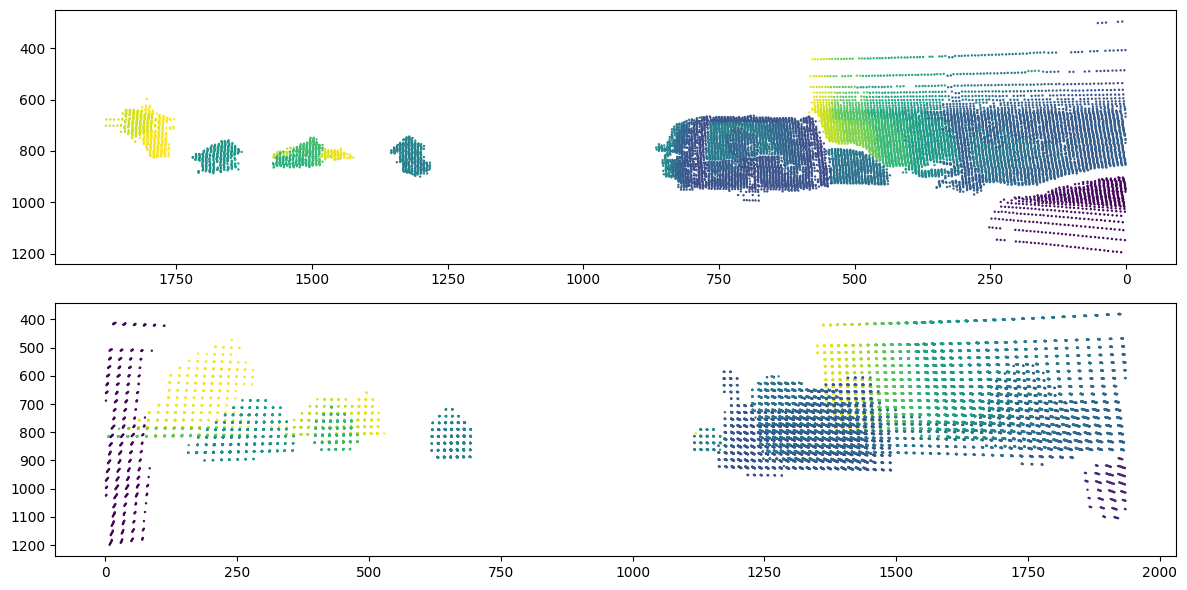

In [51]:
lidar = frames_lidar_3D[275]
radar = frames_radar_3D[275]
fig = plt.figure()
fig.set_size_inches(12, 6)

ax1 = fig.add_subplot(2, 1, 1)
ax1.scatter(lidar[:,1], lidar[:,0], c=lidar[:,2], cmap='viridis', s=0.5)
ax1.invert_yaxis()
ax1.invert_xaxis()

ax2 = fig.add_subplot(2, 1, 2)
ax2.scatter(radar[:,1], radar[:,0], c=radar[:,2], cmap='viridis', s=0.5)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

Calculate Curent Pd

Radar Cube Shape: (34, 500, 240)
Radar PC Shape: (83886, 3)
P_d: 0.5765786106720855, P_fa: 0.018398778837626823
lidar x-dim: -31.399201921910723 to 42.093567560138986
lidar x-dim: -31.399201921910723 to 42.093567560138986


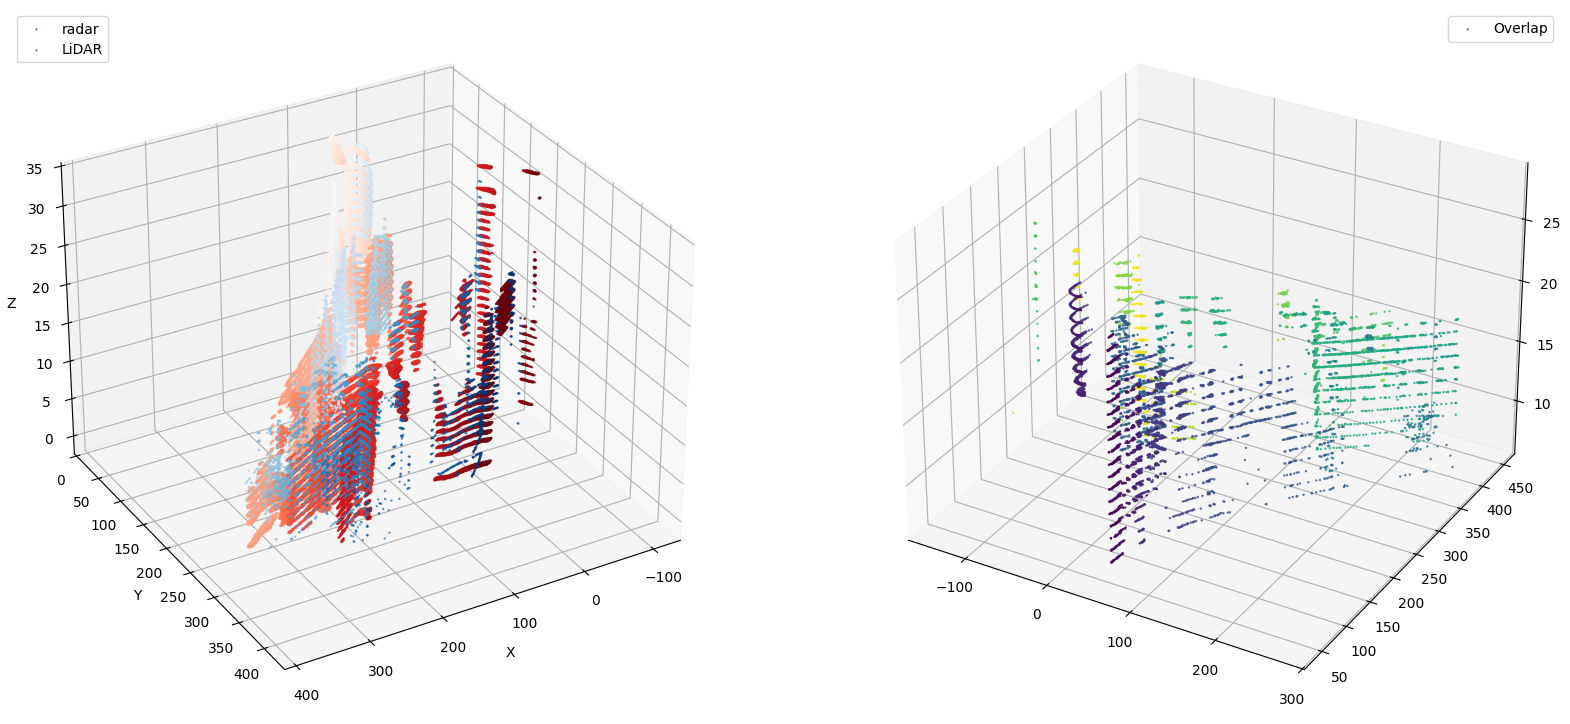

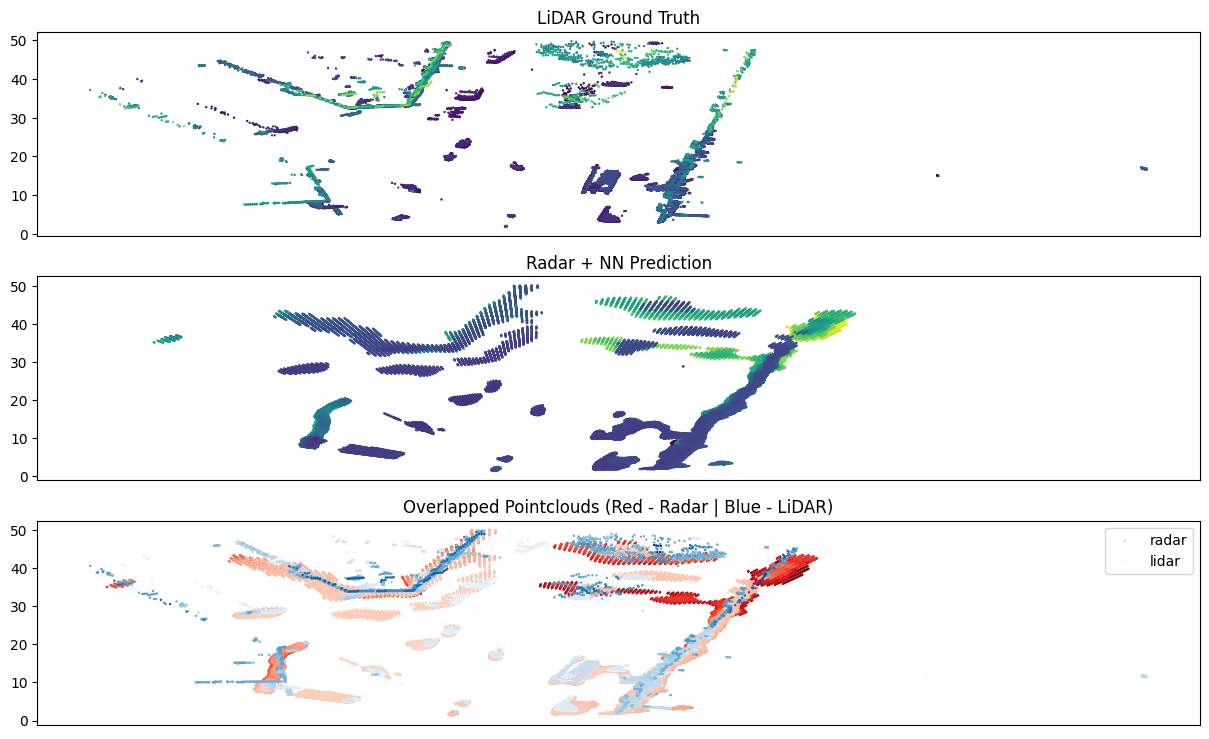

In [60]:
cam, lidar, cfar, radar = valid_data[key][275] 
# print(f"lidar: {lidar}\nradar: {radar}")

# Load / Process LiDAR
lidarpc = np.load(lidar)
lidarpc_bev = lidarpc.reshape(-1,3)
lidarpc_bev = data_preparation.transform_point_cloud(
    lidarpc_bev,
    [0, 0, params['azimuth_offset']],
    [-params['x_offset'] / 100, -params['y_offset'] / 100, 0]
)
lidarpc_bev[:, 1] = -lidarpc_bev[:, 1]
lidarpc[:, 1] = -lidarpc[:, 1]
# lidarpc[:, 0] = -lidarpc[:, 0]  # Add this line to invert y-axis
lidar_cube = data_preparation.lidarpc_to_lidarcube(lidarpc, params)

# Load / Process Radar
radar_points = np.load(radar)
if radar_points.shape[1] == 4:
    radar_points = radar_points[:, :-1]  # Remove last column (speed)
radarpc = radar_points.reshape(-1, 3)
# radarpc[:, 1] = -radarpc[:, 1]
radarpc = data_preparation.transform_point_cloud(
    radarpc,
    [0, 0, -params['azimuth_offset']],
    [-params['x_offset'] / 100, -params['y_offset'] / 100, 0]
)
radarpc_bev = radarpc
radar_cube = data_preparation.lidarpc_to_lidarcube(radar_points, params)
print(f"Radar Cube Shape: {radar_cube.shape}")
print(f"Radar PC Shape: {radarpc_bev.shape}")

# Compute Pd, Pfa
pd_radar, pfa_radar = compute_pd_pfa(lidar_cube, radar_cube)
print(f"P_d: {pd_radar}, P_fa: {pfa_radar}")

def compare_lidar_radar_cubes(radar_cube, lidar_cube, s_val=0.5):

    fig1 = plt.figure()
    fig1.set_size_inches(20, 10)
    fig2 = plt.figure()
    fig2.set_size_inches(15, 9)
    rotation_angle = 30

    # plot 3D Radar Cube
    ax0 = fig1.add_subplot(1, 2, 1, projection="3d")

    # Get indices where radar_cube has detections (non-zero values)
    z_radar, x_radar, y_radar = np.where(radar_cube > 0)

    # Rotate points 45° counter-clockwise around Z-axis
    angle = np.radians(rotation_angle)  # 45 degrees in radians
    cos_a, sin_a = np.cos(angle), np.sin(angle)

    # Apply rotation matrix
    x_rot = x_radar * cos_a - y_radar * sin_a
    y_rot = x_radar * sin_a + y_radar * cos_a
    z_rot = z_radar  # Z unchanged

    # Plot as 3D scatter where each point represents a detected cell
    ax0.scatter(
        x_rot,  # x-axis (500 dimension)
        y_rot,  # y-axis (240 dimension) 
        z_rot,  # z-axis (34 dimension)
        c=y_radar,  # Color by detection strength
        cmap='Reds',
        s=s_val,
        alpha=0.6,  # Add transparency
        label='radar'
    )
    ax0.set_xlabel('X (500)')
    ax0.set_ylabel('Y (240)')
    ax0.set_zlabel('Z (34)')
    ax0.invert_zaxis()

    # plot 3D LiDAR Cube
    # ax1 = fig1.add_subplot(1, 2, 2, projection="3d")

    # Get indices where radar_cube has detections (non-zero values)
    z_lidar, x_lidar, y_lidar = np.where(lidar_cube > 0)

    # Rotate points 45° counter-clockwise around Z-axis
    angle = np.radians(rotation_angle)  # 45 degrees in radians
    cos_a, sin_a = np.cos(angle), np.sin(angle)

    # Apply rotation matrix
    x_rot = x_lidar * cos_a - y_lidar * sin_a
    y_rot = x_lidar * sin_a + y_lidar * cos_a
    z_rot = z_lidar  # Z unchanged

    # Plot as 3D scatter where each point represents a detected cell
    ax0.scatter(
        x_rot,  # x-axis (500 dimension)
        y_rot,  # y-axis (240 dimension) 
        z_rot,  # z-axis (34 dimension)
        c=y_lidar,  # Color by detection strength
        cmap='Blues',
        s=s_val,
        alpha=0.6,  # Add transparency
        label='LiDAR'
    )
    ax0.set_xlabel('X')
    ax0.set_ylabel('Y')
    ax0.set_zlabel('Z')
    ax0.invert_zaxis()

    # Set view angle frontal to Y-axis
    ax0.view_init(elev=30, azim=60)
    ax0.legend()
    ax0.legend(loc='upper left')
    # ax1.view_init(elev=30, azim=60)

    # Plot Overlap
    ax1 = fig1.add_subplot(1, 2, 2, projection="3d")

    # Create sets of coordinate tuples for intersection
    radar_coords = set(zip(z_radar, x_radar, y_radar))
    lidar_coords = set(zip(z_lidar, x_lidar, y_lidar))

    # Find overlapping coordinates
    overlap_coords = radar_coords & lidar_coords

    if overlap_coords:
        # Convert back to arrays
        overlap_coords = np.array(list(overlap_coords))
        z_overlap = overlap_coords[:, 0]
        x_overlap = overlap_coords[:, 1] 
        y_overlap = overlap_coords[:, 2]
        
        # Apply rotation
        angle = np.radians(45)
        cos_a, sin_a = np.cos(angle), np.sin(angle)
        x_rot = x_overlap * cos_a - y_overlap * sin_a
        y_rot = x_overlap * sin_a + y_overlap * cos_a
        
        # Plot overlapping points only
        ax1.scatter(
            x_rot, y_rot, z_overlap,
            c=y_overlap,
            cmap='viridis',
            s=s_val,
            alpha=0.8,
            label='Overlap'
        )
        ax1.legend()
    else:
        print("No overlapping detections found")

    # Set view angle frontal to Y-axis
    ax0.view_init(elev=30, azim=60)
    ax0.legend()
    ax0.legend(loc='upper left')

    ax2 = fig2.add_subplot(3, 1, 1)
    ax2.scatter(lidarpc[:,1], lidarpc[:,0], c=lidarpc[:,2], cmap='viridis', s=0.5)
    ax2.set_title('LiDAR Ground Truth')
    ax2.set_xticks([])
    # ax2.invert_yaxis()
    # ax2.invert_xaxis()

    ax3 = fig2.add_subplot(3, 1, 2)
    ax3.scatter(radarpc_bev[:,1], radarpc_bev[:,0], c=radarpc_bev[:,2], cmap='viridis', s=0.5)
    ax3.set_xlim((-33.3992, 45.094))
    ax3.set_title('Radar + NN Prediction')
    ax3.set_xticks([])
    print(f"lidar x-dim: {np.min(lidarpc[:,1])} to {np.max(lidarpc[:,1])}")
    # ax3.invert_yaxis()

    ax4 = fig2.add_subplot(3, 1, 3)
    ax4.scatter(radarpc_bev[:,1], radarpc_bev[:,0], c=radarpc_bev[:,2], cmap='Reds', s=0.5, label='radar')
    ax4.scatter(lidarpc_bev[:,1], lidarpc_bev[:,0], c=lidarpc_bev[:,2], cmap='Blues', s=0.5, label='lidar')
    ax4.set_title('Overlapped Pointclouds (Red - Radar | Blue - LiDAR)')
    ax4.set_xticks([])
    ax4.legend()
    # ax4.set_xlim((-33.3992, 45.094))
    print(f"lidar x-dim: {np.min(lidarpc[:,1])} to {np.max(lidarpc[:,1])}")
    # ax3.invert_yaxis()

    plt.show()

compare_lidar_radar_cubes(radar_cube, lidar_cube)

In [86]:
def downsample_cube_max_pooling_optimized(cube, pool_size=(2, 2, 2)):
    """
    Optimized max pooling for binary cubes with your specific dimensions
    
    :param cube: 3D binary cube with shape (34, 500, 240)
    :param pool_size: pooling window size - default (2, 4, 4) gives (17, 125, 60)
    :return: downsampled cube
    """
    d, h, w = cube.shape
    pd, ph, pw = pool_size
    
    # Calculate output dimensions
    new_d = d // pd
    new_h = h // ph  
    new_w = w // pw
    
    # Trim cube to make it evenly divisible
    trimmed_cube = cube[:new_d*pd, :new_h*ph, :new_w*pw]
    
    # Reshape for pooling
    reshaped = trimmed_cube.reshape(new_d, pd, new_h, ph, new_w, pw)
    
    # Max pooling - any 1 in the pool results in 1
    downsampled = reshaped.max(axis=(1, 3, 5))
    
    return downsampled.astype(cube.dtype)

P_d: 0.425, P_fa: 0.06098114185730024


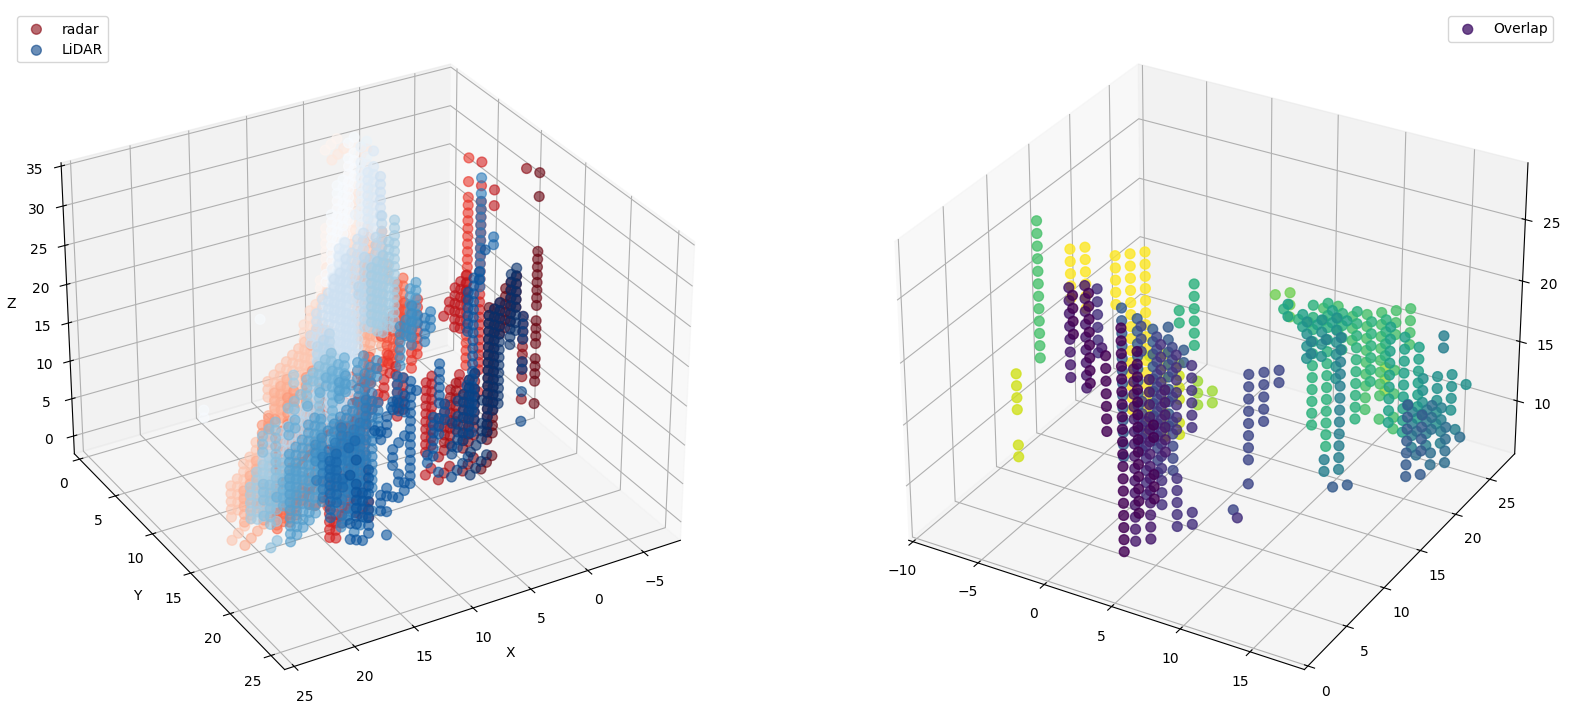

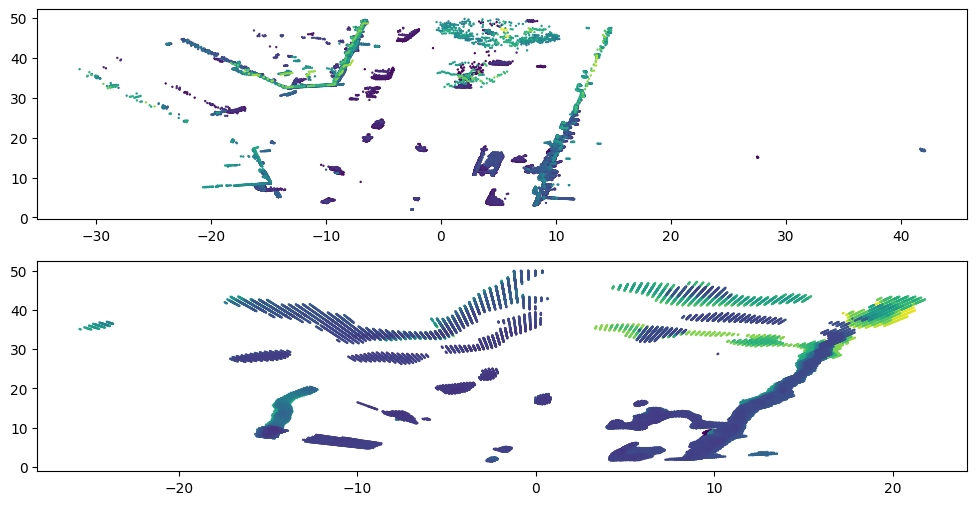

In [92]:
downsampled_radar = downsample_cube_max_pooling_optimized(radar_cube, pool_size=(1,4,4))
downsampled_lidar = downsample_cube_max_pooling_optimized(lidar_cube, pool_size=(1,4,4))
downsampled_radar = downsample_cube_max_pooling_optimized(downsampled_radar, pool_size=(1,4,4))
downsampled_lidar = downsample_cube_max_pooling_optimized(downsampled_lidar, pool_size=(1,4,4))
# Compute Pd, Pfa
pd_radar, pfa_radar = compute_pd_pfa(downsampled_lidar, downsampled_radar)
print(f"P_d: {pd_radar}, P_fa: {pfa_radar}")
compare_lidar_radar_cubes(downsampled_radar, downsampled_lidar, s_val=50)

